In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, RocCurveDisplay

from imblearn.over_sampling import SMOTE
import shap

In [19]:
# Load dataset
df = pd.read_csv("/content/ai4i2020.csv")

print(df.head())
print(df.info())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [20]:
# Drop unnecessary columns
columns_to_drop = ["UDI", "Product ID"]
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], axis=1)

In [21]:
# Encode categorical column
if df["Type"].dtype == "object":
    le = LabelEncoder()
    df["Type"] = le.fit_transform(df["Type"])

print("\nMissing values:\n", df.isnull().sum())


Missing values:
 Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [22]:
# Split features and target
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

In [23]:
# Train-test split with stratify to maintain class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
# Balance training set using SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define Random Forest
rf = RandomForestClassifier(random_state=42)

# Hyperparameter tuning using GridSearchCV to elevate model
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced']
}

In [26]:
# GridSearchCV setup
grid = GridSearchCV(estimator=rf, param_grid=param_grid,
                    cv=3, scoring='roc_auc', n_jobs=-1, verbose=2)

# Fit the grid search
grid.fit(X_res, y_res)  # Make sure X_res, y_res exist and are balanced

Fitting 3 folds for each of 108 candidates, totalling 324 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced'],
                         'max_depth': [4, 6, 8, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='roc_auc', verbose=2)

In [27]:
# Best model
best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)


Best Parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [28]:
# Predictions
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [29]:
# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.978
ROC-AUC: 0.9933321154548775

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99      1932
           1       0.61      0.96      0.75        68

    accuracy                           0.98      2000
   macro avg       0.81      0.97      0.87      2000
weighted avg       0.99      0.98      0.98      2000



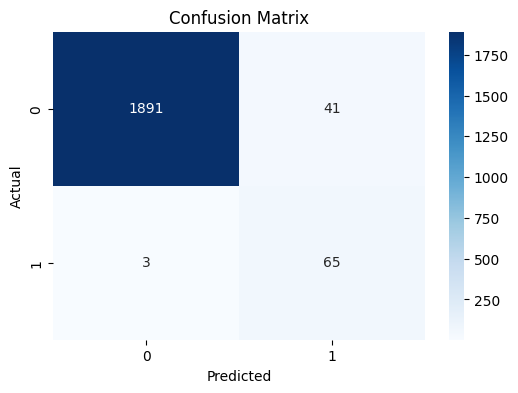

In [30]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


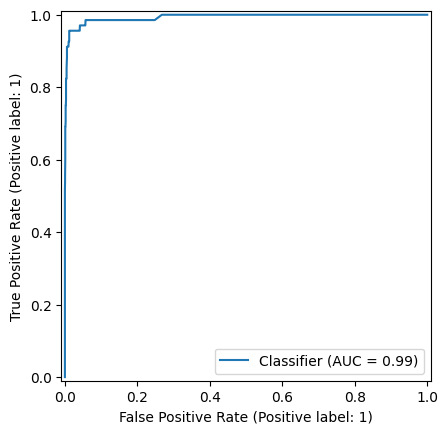

In [31]:
# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.show()

In [32]:
# Feature Importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

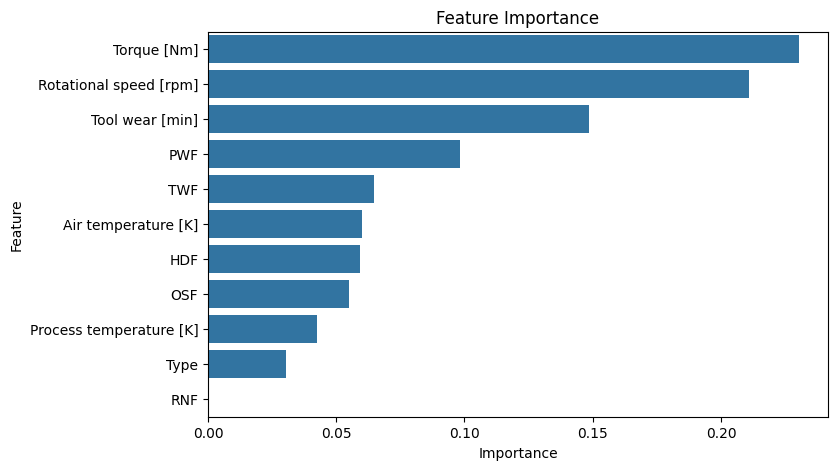

                    Feature  Importance
4               Torque [Nm]    0.230240
3    Rotational speed [rpm]    0.210774
5           Tool wear [min]    0.148589
8                       PWF    0.098191
6                       TWF    0.064839
1       Air temperature [K]    0.060063
7                       HDF    0.059125
9                       OSF    0.055110
2   Process temperature [K]    0.042386
0                      Type    0.030498
10                      RNF    0.000186


In [33]:
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importance")
plt.show()
print(importance_df)

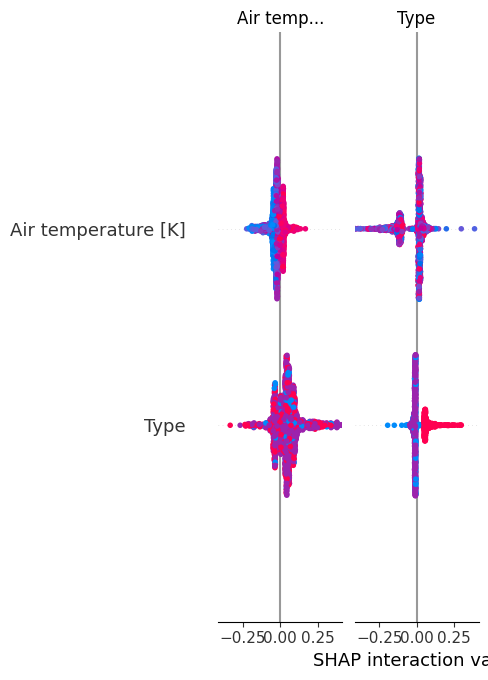

In [34]:
# SHAP interpretability
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)